# 12 — v27 at mask ratio 0.5: terrain, and does the model own the cycles?

Two questions, one model (**v27**), one regime (**mr0.50**), one lead
(**+2 h**), always split into **masked** and **visible** stations.

**Q1 — Does terrain explain the error?** Correlate per-station error against
every topographic descriptor the dataset carries. The masked/visible split is
what makes this informative: a descriptor that predicts error for *both*
subsets describes intrinsic site difficulty, whereas one that predicts error
only for masked stations describes how hard that site is to **reconstruct from
its neighbours** — a property of the network geometry, not of the site.

**Q2 — Does the model reproduce the cycles?** Error tells you how wrong a
forecast is, not whether it has the right *shape*. A model can score well on
MAE while systematically flattening the daily swing. So compare the predicted
and observed **diurnal** and **seasonal** cycles directly — amplitude ratio and
phase — for masked and visible stations separately. If masked stations show a
damped diurnal cycle, the model is reconstructing them toward the network mean
rather than resolving their local behaviour.

**Conventions.** Everything is at the fixed +2 h lead. Hour of day is **UTC**
(Swiss solar time ≈ UTC+0:32); civil local time would alias against the 90-min
origin stride via DST. At a fixed lead the origin stride leaves **16 of 24 UTC
hours populated** — ample to resolve a diurnal cycle, but the empty bins are
carried as NaN and never interpolated.

In [26]:
# ── Bootstrap ────────────────────────────────────────────────────────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
for _c in (os.getcwd(), os.path.join(os.getcwd(), "notebooks", "analysis")):
    if os.path.isfile(os.path.join(_c, "common.py")):
        if _c not in sys.path: sys.path.insert(0, _c)
        break
import importlib
import common as C
importlib.reload(C)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

RUN, MR = "v27", "mr0.50"
LEAD_MIN = 120                     # +2 h
stn = C.station_table(); ns = C.norm_stats()
VARS, STD, MEAN = ns["var_names"], ns["std"], ns["mean"]
KEEP = C.keep_mask(stn, VARS); N = len(stn)
print(f"{RUN} @ {MR}, lead +{LEAD_MIN} min · {N} stations")

v27 @ mr0.50, lead +120 min · 155 stations


## 0. Topographic descriptors

Every terrain column the dataset ships, plus three derived ones that are often
more informative than the raw fields:

* `rel_height = station_height − dem` — where the sensor sits relative to the
  modelled surface; a mast on a summit and one in a pit differ here.
* `nn_dist_km`, `n_within_30km` — network geometry, not terrain. Included
  deliberately: if reconstruction error tracks isolation rather than terrain,
  that is the finding.
* `aspect` is **circular** (0° = 360°), so it enters as `sin`/`cos`, never as a
  raw angle — a Spearman correlation on degrees would be meaningless.

In [27]:
raw = pd.read_parquet(os.path.join(C.data_root(), "stations.parquet"))
t = raw.loc[list(stn.abbr)]
TOPO = pd.DataFrame(index=list(stn.abbr))
TOPO["height"]        = t["station_height"].astype(float).values
TOPO["dem"]           = t["dem"].astype(float).values
TOPO["rel_height"]    = TOPO["height"] - TOPO["dem"]
TOPO["slope_2km"]     = t["SLOPE_2000M_SIGRATIO1"].astype(float).values
TOPO["slope_10km"]    = t["SLOPE_10000M_SIGRATIO1"].astype(float).values
TOPO["tpi_2km"]       = t["TPI_2000M"].astype(float).values
TOPO["tpi_10km"]      = t["TPI_10000M"].astype(float).values
TOPO["std_2km"]       = t["STD_2000M"].astype(float).values
TOPO["std_10km"]      = t["STD_10000M"].astype(float).values
TOPO["we_deriv_2km"]  = t["WE_DERIVATIVE_2000M_SIGRATIO1"].astype(float).values
TOPO["sn_deriv_2km"]  = t["SN_DERIVATIVE_2000M_SIGRATIO1"].astype(float).values
for tag, col in (("2km", "ASPECT_2000M_SIGRATIO1"), ("10km", "ASPECT_10000M_SIGRATIO1")):
    a = np.radians(t[col].astype(float).values)
    TOPO[f"aspect_sin_{tag}"] = np.sin(a)      # circular: never the raw angle
    TOPO[f"aspect_cos_{tag}"] = np.cos(a)
TOPO["latitude"]      = stn.latitude.values
TOPO["longitude"]     = stn.longitude.values
TOPO["nn_dist_km"]    = stn.nn_dist_km.values
TOPO["n_within_30km"] = stn.n_within_30km.values
print(f"{TOPO.shape[1]} descriptors")
display(TOPO.describe().T[["mean","std","min","max"]].round(2))

19 descriptors


,mean,std,min,max
height,1055.55,762.08,203.20,3571.33
dem,1052.79,757.76,203.59,3528.56
rel_height,2.76,7.03,-7.32,42.77
slope_2km,5.12,5.09,0.09,23.94
slope_10km,2.59,2.09,0.06,9.68
tpi_2km,2.87,109.47,-246.62,350.01
tpi_10km,-143.83,432.12,-901.64,1089.28
std_2km,70.43,66.18,0.00,246.51
std_10km,283.21,178.84,16.00,651.15
we_deriv_2km,0.01,0.09,-0.32,0.37


## 1. One streaming pass

Accumulates, at the +2 h lead only, split into masked / visible:

* per-station absolute error and count → the terrain correlations
* **sums of predicted and observed values** by UTC hour and by month → the
  cycle comparison. Errors alone cannot answer Q2: `|pred − obs|` discards the
  sign, and a damped cycle needs the signed means of both series.

In [28]:
CACHE_F = os.path.join(C.CACHE, f"n12_{RUN}_{MR}_lead{LEAD_MIN}.npz")
def build(force=False):
    if os.path.isfile(CACHE_F) and not force:
        z = np.load(CACHE_F)
        if z["n_windows"] > 0:
            print(f"loaded cache ({int(z['n_windows']):,} windows)")
            return {k: z[k] for k in z.files}
    d = C.load_dump(RUN, MR)
    P, T, M, MI = d["preds"], d["targets"], d["masks"], d["masked_idx"]
    TH = d["target_hours"]; grid = d["delta_steps"][0].numpy().astype(int)
    k = int(np.where(grid * 10 == LEAD_MIN)[0][0])
    Mw, V = P.shape[0], len(VARS)
    A = {f"{s}_{q}": np.zeros((N, V)) for s in ("msk", "vis")
         for q in ("err", "cnt")}
    A.update({f"{s}_{q}_{c}": np.zeros((24 if c == "h" else 12, N, V))
              for s in ("msk", "vis") for q in ("p", "o", "n") for c in ("h", "m")})
    ep = pd.Timestamp("1970-01-01", tz="UTC")
    CH = 1000
    for a in range(0, Mw, CH):
        b = min(a + CH, Mw)
        p = P[a:b, k].numpy().astype(np.float64) * STD[None] + MEAN[None]
        o = T[a:b, k, :, :V].numpy().astype(np.float64) * STD[None] + MEAN[None]
        m = (M[a:b, k, :, :V].numpy() > 0.5) & KEEP[None]
        mi = MI[a:b].numpy()
        sel = np.zeros((b - a, N), bool)
        np.put_along_axis(sel, mi, True, axis=1)
        ts = ep + pd.to_timedelta(TH[a:b, k].numpy().astype(np.float64), unit="h")
        hh, mm = ts.hour.values, ts.month.values - 1
        for tag, sub in (("msk", sel), ("vis", ~sel)):
            w = m & sub[:, :, None]
            A[f"{tag}_err"] += (np.abs(p - o) * w).sum(0)
            A[f"{tag}_cnt"] += w.sum(0)
            for cax, idx in (("h", hh), ("m", mm)):
                np.add.at(A[f"{tag}_p_{cax}"], idx, p * w)
                np.add.at(A[f"{tag}_o_{cax}"], idx, o * w)
                np.add.at(A[f"{tag}_n_{cax}"], idx, w.astype(float))
    A["n_windows"] = np.array(Mw)
    A["lead_k"] = np.array(k)
    np.savez_compressed(CACHE_F, **A)
    print(f"streamed {Mw:,} windows at lead index {k} (+{LEAD_MIN} min)")
    return A

A = build()
MAE = {s: np.where(A[f"{s}_cnt"] > 100, A[f"{s}_err"]/np.maximum(A[f"{s}_cnt"],1),
                   np.nan) for s in ("msk", "vis")}
PEN = MAE["msk"] - MAE["vis"]
print("per-station MAE at +2h  (physical units, NaN where no data):")
display(pd.DataFrame({f"{s} {v}": MAE[s][:, i] for i, v in enumerate(VARS)
                      for s in ("msk","vis")}, index=list(stn.abbr)).head(4).round(3))

loaded cache (11,684 windows)
per-station MAE at +2h  (physical units, NaN where no data):


,msk temperature,vis temperature,msk pressure,vis pressure,msk humidity,vis humidity,msk wind_u,vis wind_u,msk wind_v,vis wind_v
ABO,0.906,0.746,0.426,0.358,5.864,4.950,0.803,0.797,0.858,0.818
AEG,NaN,NaN,NaN,NaN,NaN,NaN,1.072,1.053,0.781,0.793
AIG,0.904,0.735,0.510,0.398,4.828,4.179,0.674,0.678,1.090,1.032
ALT,0.957,0.721,0.505,0.382,4.808,4.114,0.716,0.687,1.025,0.968


## 2. Terrain correlations

Spearman between each descriptor and per-station error, for masked and visible
separately, plus the masking penalty. With N≈155, |ρ| below ≈0.16 is
indistinguishable from zero — the threshold is drawn on the figure.

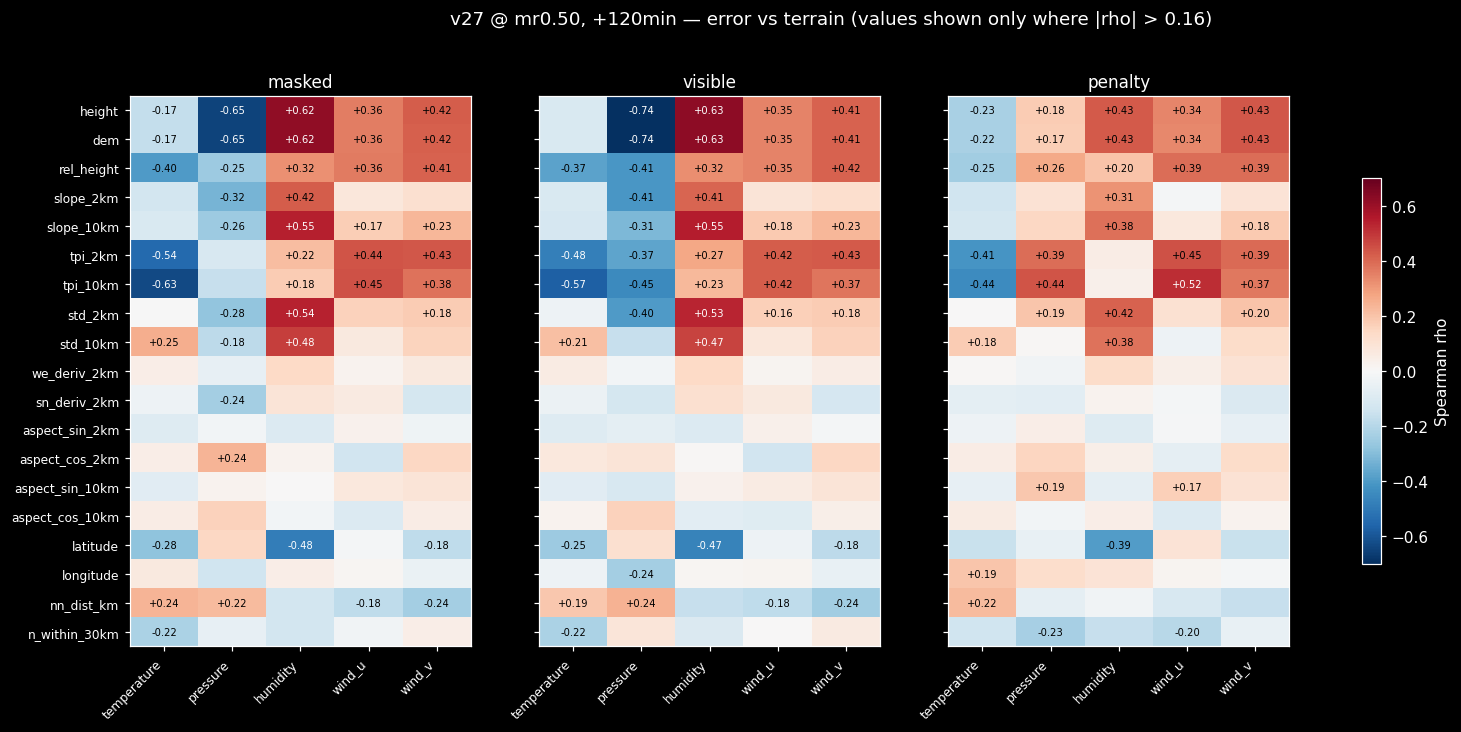

In [29]:
def rho(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 12: return np.nan
    return float(np.corrcoef(np.argsort(np.argsort(a[m])),
                             np.argsort(np.argsort(b[m])))[0, 1])

blocks = {"masked": MAE["msk"], "visible": MAE["vis"], "penalty": PEN}
CORR = {kk: pd.DataFrame(
            {v: [rho(TOPO[c].values, arr[:, i]) for c in TOPO.columns]
             for i, v in enumerate(VARS)}, index=TOPO.columns)
        for kk, arr in blocks.items()}
thr = 2/np.sqrt(np.isfinite(MAE["msk"][:, 0]).sum())
fig, axes = plt.subplots(1, 3, figsize=(17, 6.5), sharey=True)
for ax, (kk, cm) in zip(axes, CORR.items()):
    im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-.7, vmax=.7, aspect="auto")
    ax.set_xticks(range(len(VARS)))
    ax.set_xticklabels(VARS, rotation=45, ha="right", fontsize=8)
    ax.set_title(kk, fontsize=11)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm.values[i, j]
            if np.isfinite(val) and abs(val) > thr:
                ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                        fontsize=6.5,
                        color="white" if abs(val) > .45 else "black")
axes[0].set_yticks(range(len(TOPO.columns)))
axes[0].set_yticklabels(TOPO.columns, fontsize=8)
fig.colorbar(im, ax=axes, shrink=.7, label="Spearman rho")
fig.suptitle(f"{RUN} @ {MR}, +{LEAD_MIN}min — error vs terrain "
             f"(values shown only where |rho| > {thr:.2f})", y=1.0)
C.save_fig(fig, "12_terrain_correlations"); plt.show()
for kk, cm in CORR.items(): C.save_table(cm, f"12_corr_{kk}")

In [30]:
# strongest relationships, ranked
best = []
for kk, cm in CORR.items():
    for c in cm.index:
        for v in cm.columns:
            r = cm.loc[c, v]
            if np.isfinite(r) and abs(r) > thr:
                best.append({"subset": kk, "descriptor": c, "variable": v,
                             "rho": r})
best = pd.DataFrame(best).reindex(
    pd.DataFrame(best).rho.abs().sort_values(ascending=False).index)
display(best.head(18).round(3))
print(f"\nsignificance threshold |rho| > {thr:.3f}  (N = "
      f"{int(np.isfinite(MAE['msk'][:,0]).sum())} stations)")

,subset,descriptor,variable,rho
45,visible,height,pressure,-0.744
49,visible,dem,pressure,-0.742
6,masked,dem,pressure,-0.648
1,masked,height,pressure,-0.647
25,masked,tpi_10km,temperature,-0.630
46,visible,height,humidity,0.628
50,visible,dem,humidity,0.627
2,masked,height,humidity,0.623
7,masked,dem,humidity,0.622
69,visible,tpi_10km,temperature,-0.573



significance threshold |rho| > 0.164  (N = 149 stations)


## 3. Terrain or isolation? A joint fit

Height, slope, TPI and roughness are strongly correlated with one another, so
a single marginal correlation cannot say which one carries the signal. A
standardised multiple regression gives each descriptor's contribution with the
others held fixed. Coefficients are in units of "σ of error per σ of
descriptor", so they are directly comparable.

In [31]:
def standardise(X):
    mu, sd = np.nanmean(X, 0), np.nanstd(X, 0)
    return (X - mu) / np.where(sd > 0, sd, 1)

SUBSET = ["height", "rel_height", "slope_2km", "tpi_10km", "std_2km",
          "nn_dist_km", "n_within_30km"]
rows = {}
for kk, arr in blocks.items():
    for i, v in enumerate(VARS):
        y = arr[:, i]
        X = TOPO[SUBSET].values
        m = np.isfinite(y) & np.isfinite(X).all(1)
        if m.sum() < 30: continue
        Xs, ys = standardise(X[m]), (y[m]-np.nanmean(y[m]))/np.nanstd(y[m])
        Xd = np.column_stack([np.ones(m.sum()), Xs])
        beta, *_ = np.linalg.lstsq(Xd, ys, rcond=None)
        pred = Xd @ beta
        r2 = 1 - ((ys-pred)**2).sum()/((ys-ys.mean())**2).sum()
        rows[(kk, v)] = dict(zip(SUBSET, beta[1:])) | {"R2": r2}
REG = pd.DataFrame(rows).T
REG.index.names = ["subset", "variable"]
display(REG.round(3).style.background_gradient(cmap="RdBu_r", vmin=-.6, vmax=.6,
                                               subset=SUBSET)
        .set_caption("standardised regression coefficients (sigma of error per "
                     "sigma of descriptor), with R2 of the joint fit"))
C.save_table(REG, "12_terrain_regression")

'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/analysis_outputs/tables/12_terrain_regression.csv'

## 4. Diurnal cycle — does the model keep the swing?

Mean predicted and mean observed value by UTC hour, per variable, for masked
and visible stations. Two summaries:

* **amplitude ratio** = (max−min of predicted hourly means) ÷ (same for
  observed). 1 = the daily swing is reproduced; below 1 = damped.
* **phase shift** = hour of the predicted maximum − hour of the observed
  maximum. Non-zero means the model is early or late.

A damped cycle on masked stations specifically would mean the model
reconstructs a hidden site toward the network's average day rather than
resolving its own.

/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_20788/3424503276.py:20: RuntimeWarning: Mean of empty slice
  pm = np.nanmean(ph_[:, :, ci], 1); om = np.nanmean(oh_[:, :, ci], 1)
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_20788/3424503276.py:9: RuntimeWarning: All-NaN slice encountered
  a = np.nanmax(mean_cycle, 0) - np.nanmin(mean_cycle, 0)


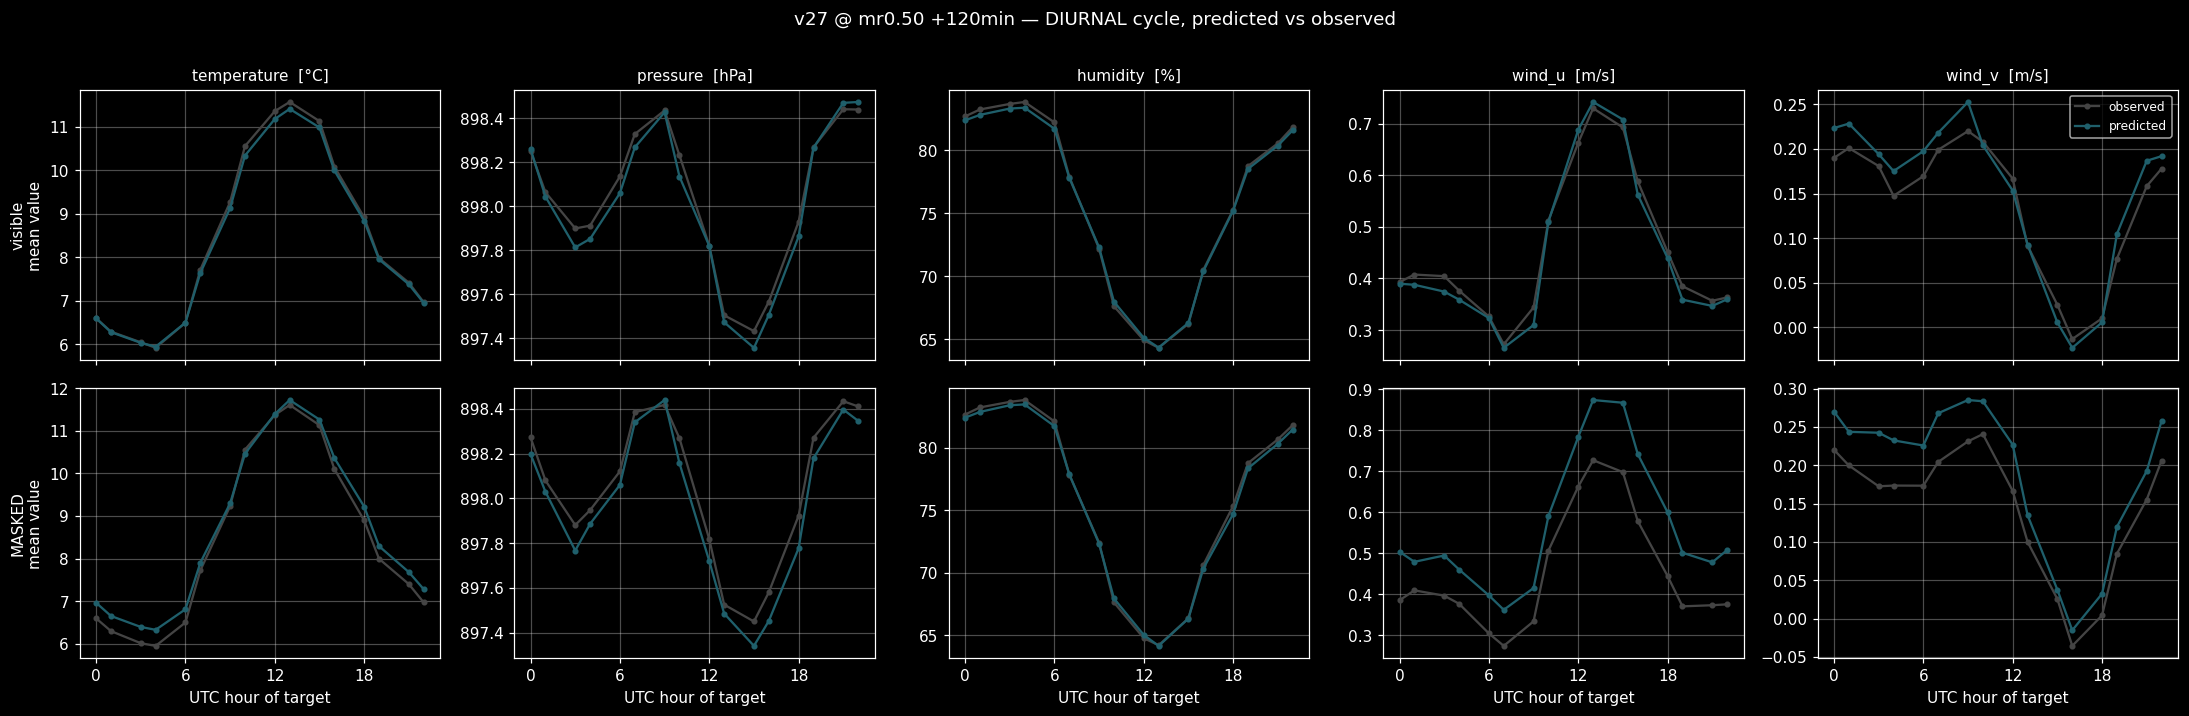

'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/analysis_outputs/tables/12_diurnal_summary.csv'

In [32]:
def cycles(tag, cax):
    p = A[f"{tag}_p_{cax}"]; o = A[f"{tag}_o_{cax}"]; n = A[f"{tag}_n_{cax}"]
    with np.errstate(invalid="ignore"):
        return (np.where(n > 50, p/np.maximum(n,1), np.nan),
                np.where(n > 50, o/np.maximum(n,1), np.nan), n)

def amp_phase(mean_cycle):
    """(amplitude, argmax) over populated bins; NaN-safe."""
    a = np.nanmax(mean_cycle, 0) - np.nanmin(mean_cycle, 0)
    ph = np.nanargmax(np.where(np.isfinite(mean_cycle), mean_cycle, -np.inf), 0)
    return a, ph

fig, axes = plt.subplots(2, len(VARS), figsize=(4.0*len(VARS), 6.4), sharex=True)
summ = {}
for ri, tag in enumerate(("vis", "msk")):
    ph_, oh_, nh = cycles(tag, "h")
    filled = np.where(np.nansum(nh[:, :, 0], 1) > 0)[0]
    for ci, v in enumerate(VARS):
        ax = axes[ri, ci]
        pm = np.nanmean(ph_[:, :, ci], 1); om = np.nanmean(oh_[:, :, ci], 1)
        ax.plot(filled, om[filled], "o-", ms=3, color="#444", label="observed")
        ax.plot(filled, pm[filled], "o-", ms=3, color=C.MODELS[RUN][1],
                label="predicted")
        ax.grid(alpha=.3); ax.set_xticks(range(0, 24, 6))
        if ri == 0: ax.set_title(f"{v}  [{C.UNITS[v]}]", fontsize=10)
        if ri == 1: ax.set_xlabel("UTC hour of target")
        if ci == 0: ax.set_ylabel(f"{'visible' if tag=='vis' else 'MASKED'}\nmean value")
    ap, php = amp_phase(ph_); ao, pho = amp_phase(oh_)
    summ[tag] = pd.DataFrame({
        "amp_ratio": np.nanmean(ap/np.where(ao > 1e-9, ao, np.nan), 0),
        "phase_shift_h": np.nanmean(((php - pho + 12) % 24) - 12, 0),
        "obs_amplitude": np.nanmean(ao, 0)}, index=VARS)
axes[0, -1].legend(fontsize=8)
fig.suptitle(f"{RUN} @ {MR} +{LEAD_MIN}min — DIURNAL cycle, predicted vs observed",
             y=1.01)
plt.tight_layout(); C.save_fig(fig, "12_diurnal_cycle"); plt.show()
dsum = pd.concat(summ, names=["subset"])
display(dsum.round(3).style.background_gradient(cmap="RdYlGn", vmin=.5, vmax=1.1,
                                                subset=["amp_ratio"])
        .set_caption("amp_ratio 1 = swing reproduced, <1 = damped; "
                     "phase_shift in hours, + = model peaks late"))
C.save_table(dsum, "12_diurnal_summary")

## 5. Seasonal cycle

The same test on monthly means. The seasonal cycle is far slower than the +2 h
forecast horizon, so a model with any skill should reproduce it almost
perfectly — this is closer to a sanity check than a challenge, and a failure
here would point at the normalisation rather than the forecast.

/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_20788/3424503276.py:9: RuntimeWarning: All-NaN slice encountered
  a = np.nanmax(mean_cycle, 0) - np.nanmin(mean_cycle, 0)
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_20788/3424503276.py:9: RuntimeWarning: All-NaN slice encountered
  a = np.nanmax(mean_cycle, 0) - np.nanmin(mean_cycle, 0)


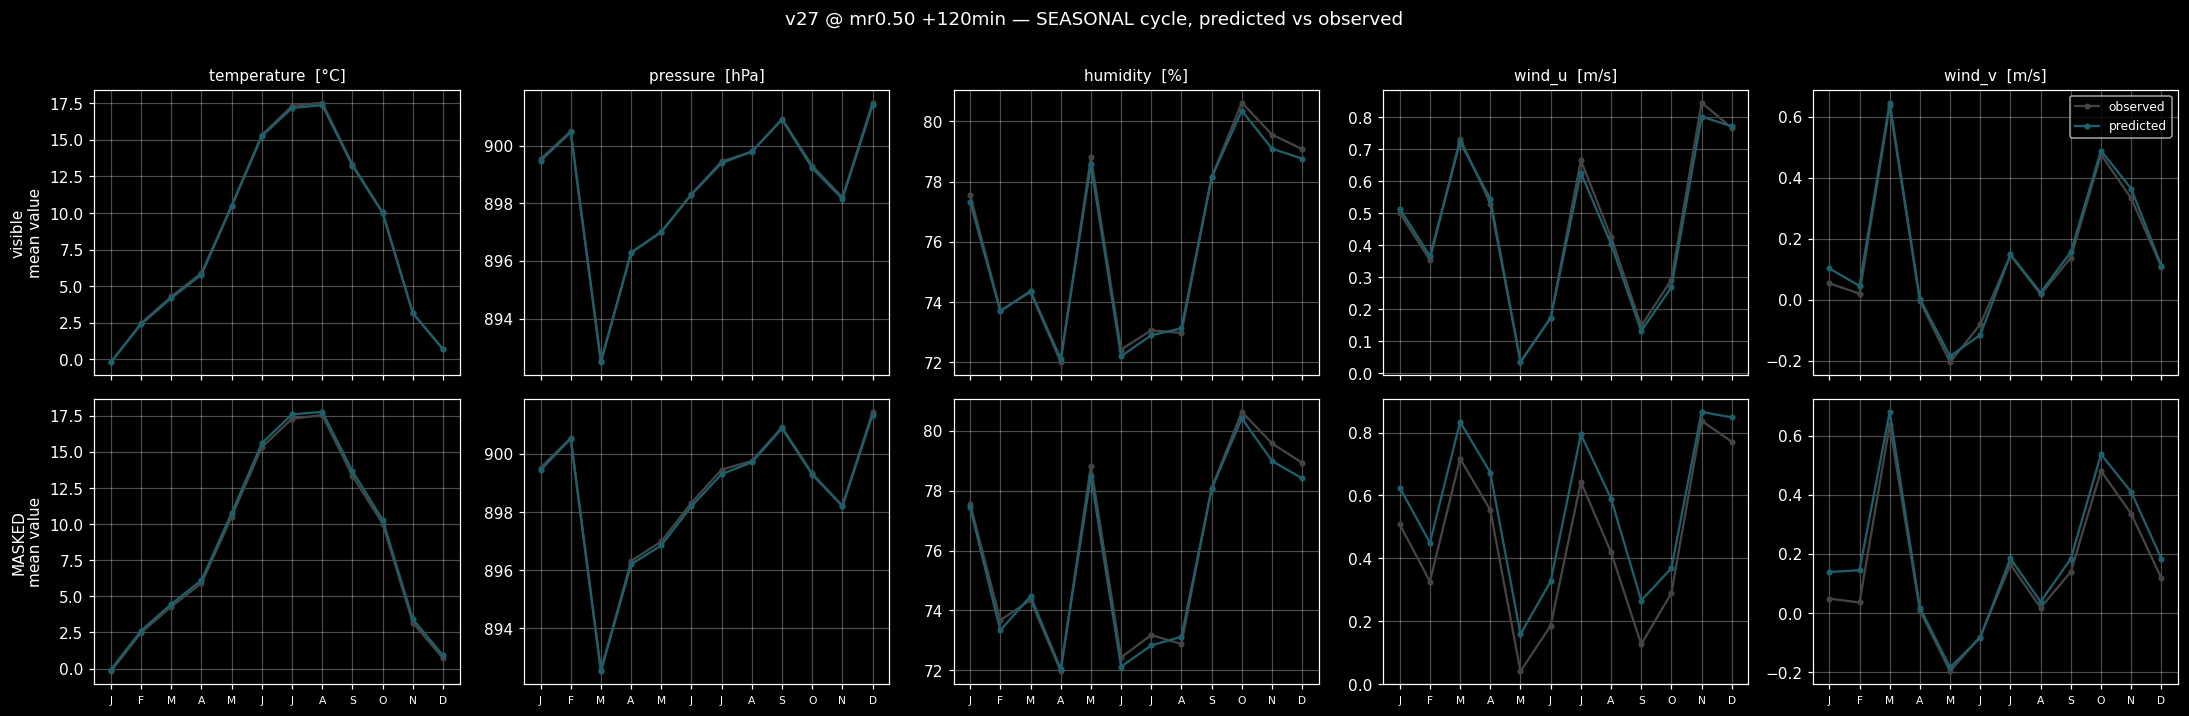

/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_20788/3424503276.py:9: RuntimeWarning: All-NaN slice encountered
  a = np.nanmax(mean_cycle, 0) - np.nanmin(mean_cycle, 0)


,temperature,pressure,humidity,wind_u,wind_v
height,-0.280000,-0.260000,-0.090000,-0.070000,0.070000
dem,-0.290000,-0.260000,-0.090000,-0.070000,0.070000
rel_height,-0.070000,0.050000,0.090000,-0.010000,-0.060000
slope_2km,-0.220000,-0.210000,-0.100000,-0.120000,0.130000
slope_10km,-0.240000,-0.200000,-0.060000,-0.060000,0.110000
tpi_2km,-0.020000,0.100000,0.190000,0.090000,-0.090000
tpi_10km,-0.030000,0.110000,0.140000,0.120000,-0.060000
std_2km,-0.170000,-0.140000,0.000000,-0.160000,0.120000
std_10km,-0.150000,-0.170000,0.000000,-0.110000,0.120000
we_deriv_2km,-0.030000,-0.090000,0.330000,-0.100000,-0.060000


'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/analysis_outputs/tables/12_damping_vs_terrain.csv'

In [33]:
fig, axes = plt.subplots(2, len(VARS), figsize=(4.0*len(VARS), 6.4), sharex=True)
ssum = {}
MONTHS = ["J","F","M","A","M","J","J","A","S","O","N","D"]
for ri, tag in enumerate(("vis", "msk")):
    pm_, om_, nm = cycles(tag, "m")
    for ci, v in enumerate(VARS):
        ax = axes[ri, ci]
        ax.plot(range(12), np.nanmean(om_[:, :, ci], 1), "o-", ms=3,
                color="#444", label="observed")
        ax.plot(range(12), np.nanmean(pm_[:, :, ci], 1), "o-", ms=3,
                color=C.MODELS[RUN][1], label="predicted")
        ax.grid(alpha=.3); ax.set_xticks(range(12))
        ax.set_xticklabels(MONTHS, fontsize=7)
        if ri == 0: ax.set_title(f"{v}  [{C.UNITS[v]}]", fontsize=10)
        if ci == 0: ax.set_ylabel(f"{'visible' if tag=='vis' else 'MASKED'}\nmean value")
    ap, php = amp_phase(pm_); ao, pho = amp_phase(om_)
    ssum[tag] = pd.DataFrame({
        "amp_ratio": np.nanmean(ap/np.where(ao > 1e-9, ao, np.nan), 0),
        "phase_shift_months": np.nanmean(((php - pho + 6) % 12) - 6, 0),
        "obs_amplitude": np.nanmean(ao, 0)}, index=VARS)
axes[0, -1].legend(fontsize=8)
fig.suptitle(f"{RUN} @ {MR} +{LEAD_MIN}min — SEASONAL cycle, predicted vs observed",
             y=1.01)
plt.tight_layout(); C.save_fig(fig, "12_seasonal_cycle"); plt.show()
smry = pd.concat(ssum, names=["subset"])
display(smry.round(3).style.background_gradient(cmap="RdYlGn", vmin=.5, vmax=1.1,
                                                subset=["amp_ratio"])
        .set_caption("seasonal amplitude ratio and phase shift (months)"))
C.save_table(smry, "12_seasonal_summary")

# per-station diurnal damping vs terrain — the two halves of the notebook meet
ph_, oh_, nh = cycles("msk", "h")
ap, _ = amp_phase(ph_); ao, _ = amp_phase(oh_)
damp = ap / np.where(ao > 1e-9, ao, np.nan)          # (N, V)
tbl = pd.DataFrame({v: [rho(TOPO[c].values, damp[:, i]) for c in TOPO.columns]
                    for i, v in enumerate(VARS)}, index=TOPO.columns)
display(tbl.round(2).style.background_gradient(cmap="RdBu_r", vmin=-.6, vmax=.6)
        .set_caption("Spearman: terrain vs DIURNAL DAMPING of masked stations "
                     "(negative = the model flattens that site's day more)"))
C.save_table(tbl, "12_damping_vs_terrain")

## 6. Which variables are terrain-sensitive? A per-variable ranking

Section 2 gives one heatmap per subset (masked / visible / penalty), with all
five variables as columns. Flipped the other way: for a given variable, is
*any* terrain descriptor a strong predictor of its error, or is that
variable essentially terrain-blind? Ranks the five variables by their
strongest |rho| against any descriptor, subsets kept separate throughout —
"strong for masked stations" and "strong for visible stations" are different
claims and are not collapsed into one number.

,masked,visible,penalty,overall_max
pressure,0.648000,0.744000,0.441000,0.744000
temperature,0.630000,0.573000,0.439000,0.630000
humidity,0.623000,0.628000,0.429000,0.628000
wind_u,0.447000,0.423000,0.519000,0.519000
wind_v,0.433000,0.428000,0.434000,0.434000


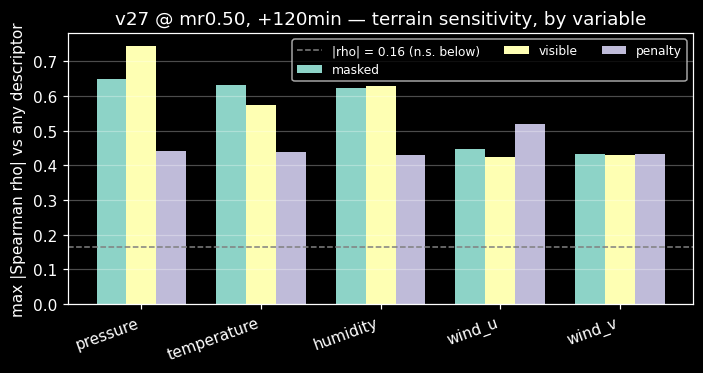

Strongest single descriptor per variable, per subset:
  temperature:
    masked    tpi_10km          rho=-0.630
    visible   tpi_10km          rho=-0.573
    penalty   tpi_10km          rho=-0.439
  pressure:
    masked    dem               rho=-0.648
    visible   height            rho=-0.744
    penalty   tpi_10km          rho=+0.441
  humidity:
    masked    height            rho=+0.623
    visible   height            rho=+0.628
    penalty   height            rho=+0.429
  wind_u:
    masked    tpi_10km          rho=+0.447
    visible   tpi_2km           rho=+0.423
    penalty   tpi_10km          rho=+0.519
  wind_v:
    masked    tpi_2km           rho=+0.433
    visible   tpi_2km           rho=+0.428
    penalty   height            rho=+0.434


'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/analysis_outputs/tables/12_terrain_sensitivity_by_variable.csv'

In [34]:
sens = pd.DataFrame({v: {kk: CORR[kk][v].abs().max() for kk in CORR} for v in VARS}).T
sens["overall_max"] = sens.max(axis=1)
sens = sens.sort_values("overall_max", ascending=False)
display(sens.round(3).style.set_caption(
    "max |Spearman rho| vs ANY terrain descriptor, by variable and subset "
    f"(significance threshold |rho| > {thr:.2f})"))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
order = sens.index
x = np.arange(len(order))
w = 0.25
for i, kk in enumerate(CORR):
    ax.bar(x + (i - 1) * w, sens.loc[order, kk], width=w, label=kk)
ax.axhline(thr, color="grey", ls="--", lw=1, label=f"|rho| = {thr:.2f} (n.s. below)")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("max |Spearman rho| vs any descriptor")
ax.set_title(f"{RUN} @ {MR}, +{LEAD_MIN}min — terrain sensitivity, by variable")
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(alpha=.3, axis="y")
plt.tight_layout(); C.save_fig(fig, "12_terrain_sensitivity_by_variable"); plt.show()

print("Strongest single descriptor per variable, per subset:")
for v in VARS:
    print(f"  {v}:")
    for kk in CORR:
        col = CORR[kk][v]
        if col.abs().max() <= thr or col.isna().all():
            print(f"    {kk:8s}  -- no descriptor exceeds the significance threshold")
            continue
        top = col.abs().idxmax()
        print(f"    {kk:8s}  {top:16s}  rho={col[top]:+.3f}")
C.save_table(sens, "12_terrain_sensitivity_by_variable")

## 7. Does the height correlation depend on season or time of day?

Section 2's terrain correlations pool every test window at the fixed +2 h
lead. If alpine stations are hardest specifically under winter temperature
inversions, or specifically overnight when the boundary layer decouples, that
signal is averaged away in the pooled number. Re-run the same
height-vs-error correlation, but computed **separately per season** (DJF /
MAM / JJA / SON) and **separately per 6-hour UTC time-of-day bin**, still
split into masked / visible.

New streaming pass (own cache — section 1's cache has no time breakdown of
the error, only of the raw values used for the cycle plots).

In [35]:
CACHE_F2 = os.path.join(C.CACHE, f"n12_season_tod_{RUN}_{MR}_lead{LEAD_MIN}.npz")

def build_season_tod(force=False):
    if os.path.isfile(CACHE_F2) and not force:
        z = np.load(CACHE_F2)
        if z["n_windows"] > 0:
            print(f"loaded cache ({int(z['n_windows']):,} windows)")
            return {k: z[k] for k in z.files}
    d = C.load_dump(RUN, MR)
    P, T, M, MI = d["preds"], d["targets"], d["masks"], d["masked_idx"]
    TH = d["target_hours"]; grid = d["delta_steps"][0].numpy().astype(int)
    k = int(np.where(grid * 10 == LEAD_MIN)[0][0])
    Mw, V = P.shape[0], len(VARS)
    B = {f"{s}_{q}_{c}": np.zeros((4, N, V))
         for s in ("msk", "vis") for q in ("err", "cnt") for c in ("season", "tod")}
    CH = 1000
    for a in range(0, Mw, CH):
        b = min(a + CH, Mw)
        p = P[a:b, k].numpy().astype(np.float64) * STD[None] + MEAN[None]
        o = T[a:b, k, :, :V].numpy().astype(np.float64) * STD[None] + MEAN[None]
        m = (M[a:b, k, :, :V].numpy() > 0.5) & KEEP[None]
        mi = MI[a:b].numpy()
        sel = np.zeros((b - a, N), bool)
        np.put_along_axis(sel, mi, True, axis=1)

        th = TH[a:b, k].numpy().astype(np.float64)
        season_idx = C._season_of(th).astype(int)                      # 0=DJF..3=SON
        ts = pd.Timestamp("1970-01-01", tz="UTC") + pd.to_timedelta(th, unit="h")
        tod_idx = (ts.hour.values // 6).astype(int)                    # 0=00-06 UTC .. 3=18-24 UTC

        err = np.abs(p - o)                                            # (b-a, N, V)
        for tag, sub in (("msk", sel), ("vis", ~sel)):
            w = m & sub[:, :, None]
            for cax, idx in (("season", season_idx), ("tod", tod_idx)):
                np.add.at(B[f"{tag}_err_{cax}"], idx, err * w)
                np.add.at(B[f"{tag}_cnt_{cax}"], idx, w.astype(float))
    B["n_windows"] = np.array(Mw)
    np.savez_compressed(CACHE_F2, **B)
    print(f"streamed {Mw:,} windows (season / time-of-day split) at lead index {k}")
    return B

B = build_season_tod()

SEASON_LABELS = ["DJF", "MAM", "JJA", "SON"]
TOD_LABELS    = ["00\u201306 UTC", "06\u201312 UTC", "12\u201318 UTC", "18\u201324 UTC"]
MIN_CNT_BIN   = 50   # per-station-variable count floor within a season/time-of-day bin

def bin_mae(tag, cax):
    err, cnt = B[f"{tag}_err_{cax}"], B[f"{tag}_cnt_{cax}"]
    return np.where(cnt > MIN_CNT_BIN, err / np.maximum(cnt, 1), np.nan)   # (4, N, V)

MAE_SEASON = {s: bin_mae(s, "season") for s in ("msk", "vis")}
MAE_TOD    = {s: bin_mae(s, "tod")    for s in ("msk", "vis")}

loaded cache (11,684 windows)


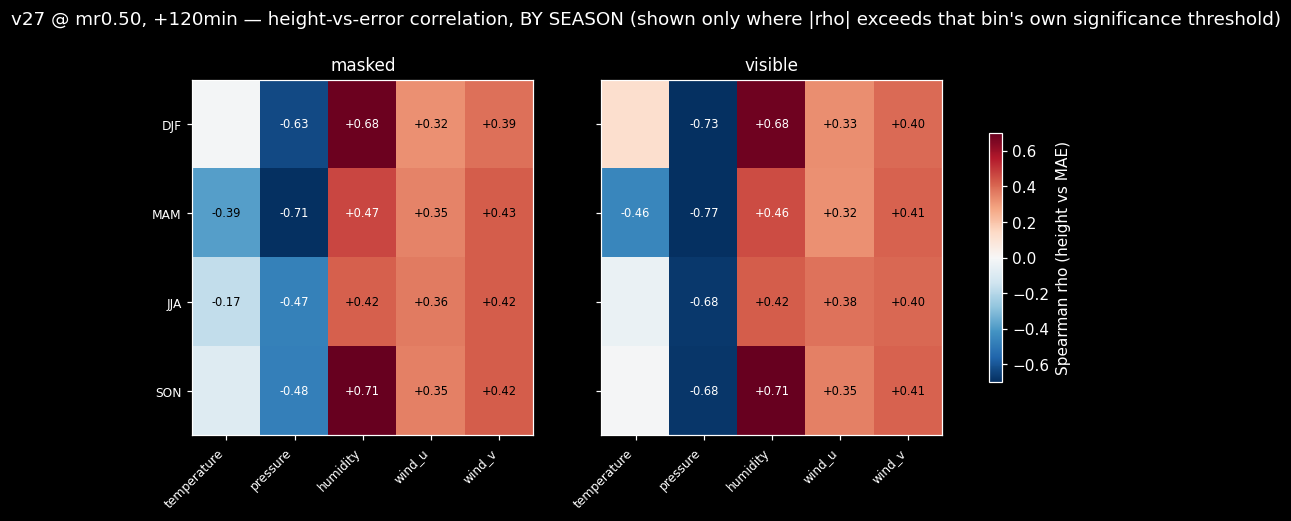

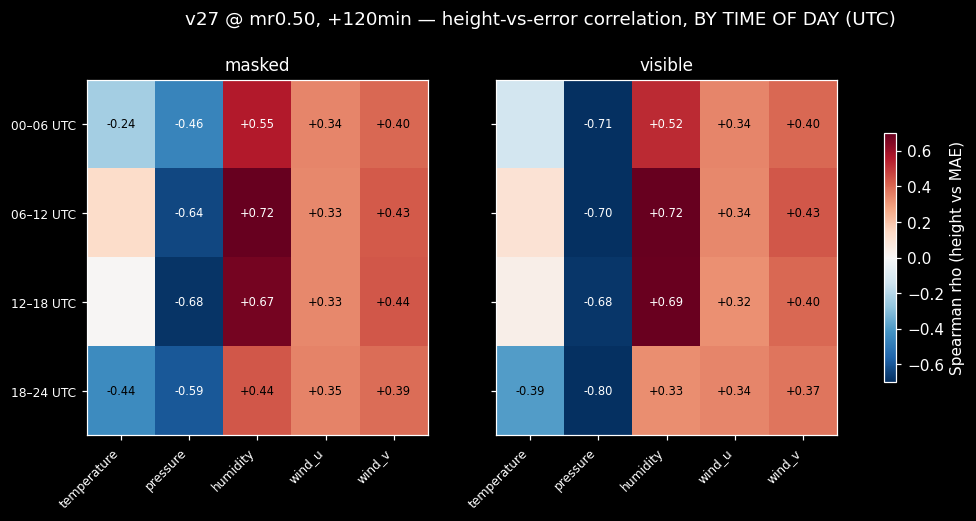

Strongest season per variable (masked stations, |rho| ranked):
  temperature  strongest in  MAM  rho=-0.385  (n=149 stations)
  pressure     strongest in  MAM  rho=-0.709  (n=138 stations)
  humidity     strongest in  SON  rho=+0.712  (n=148 stations)
  wind_u       strongest in  JJA  rho=+0.362  (n=150 stations)
  wind_v       strongest in  MAM  rho=+0.426  (n=150 stations)

Strongest time-of-day bin per variable (masked stations, |rho| ranked):
  temperature  strongest in   18–24 UTC  rho=-0.439  (n=149 stations)
  pressure     strongest in   12–18 UTC  rho=-0.684  (n=138 stations)
  humidity     strongest in   06–12 UTC  rho=+0.717  (n=149 stations)
  wind_u       strongest in   18–24 UTC  rho=+0.346  (n=150 stations)
  wind_v       strongest in   12–18 UTC  rho=+0.436  (n=150 stations)


In [36]:
def height_rho_by_bin(mae_by_bin, labels, descriptor="height"):
    """rho(TOPO[descriptor], per-station MAE) for every (bin, subset, variable)."""
    rows = []
    for si, lab in enumerate(labels):
        for tag in ("msk", "vis"):
            for vi, v in enumerate(VARS):
                vals = mae_by_bin[tag][si, :, vi]
                r = rho(TOPO[descriptor].values, vals)
                rows.append({"bin": lab, "subset": tag, "variable": v, "rho": r,
                            "n_stations": int(np.isfinite(vals).sum())})
    return pd.DataFrame(rows)

season_rho = height_rho_by_bin(MAE_SEASON, SEASON_LABELS)
tod_rho    = height_rho_by_bin(MAE_TOD, TOD_LABELS)

def plot_bin_rho(df, labels, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, tag in zip(axes, ("msk", "vis")):
        sub = df[df["subset"] == tag]
        piv = sub.pivot(index="bin", columns="variable", values="rho").reindex(labels)[VARS]
        n_piv = sub.pivot(index="bin", columns="variable", values="n_stations").reindex(labels)[VARS]
        im = ax.imshow(piv.values, cmap="RdBu_r", vmin=-.7, vmax=.7, aspect="auto")
        ax.set_xticks(range(len(VARS))); ax.set_xticklabels(VARS, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title("masked" if tag == "msk" else "visible", fontsize=11)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                val, n = piv.values[i, j], n_piv.values[i, j]
                if not np.isfinite(val):
                    continue
                local_thr = 2 / np.sqrt(max(n, 1))
                if abs(val) > local_thr:
                    ax.text(j, i, f"{val:+.2f}", ha="center", va="center", fontsize=7.5,
                           color="white" if abs(val) > .45 else "black")
    fig.colorbar(im, ax=axes, shrink=.7, label="Spearman rho (height vs MAE)")
    fig.suptitle(title, y=1.03)
    C.save_fig(fig, save_name); plt.show()

plot_bin_rho(season_rho, SEASON_LABELS,
            f"{RUN} @ {MR}, +{LEAD_MIN}min \u2014 height-vs-error correlation, BY SEASON "
            "(shown only where |rho| exceeds that bin's own significance threshold)",
            "12_height_corr_by_season")
plot_bin_rho(tod_rho, TOD_LABELS,
            f"{RUN} @ {MR}, +{LEAD_MIN}min \u2014 height-vs-error correlation, BY TIME OF DAY (UTC)",
            "12_height_corr_by_timeofday")

C.save_table(season_rho, "12_height_corr_by_season")
C.save_table(tod_rho, "12_height_corr_by_timeofday")

print("Strongest season per variable (masked stations, |rho| ranked):")
for v in VARS:
    sub = season_rho[(season_rho.subset == "msk") & (season_rho.variable == v)].dropna(subset=["rho"])
    if sub.empty:
        print(f"  {v}: no valid bins"); continue
    top = sub.reindex(sub.rho.abs().sort_values(ascending=False).index).iloc[0]
    print(f"  {v:<12} strongest in {top['bin']:>4}  rho={top['rho']:+.3f}  (n={int(top['n_stations'])} stations)")

print("\nStrongest time-of-day bin per variable (masked stations, |rho| ranked):")
for v in VARS:
    sub = tod_rho[(tod_rho.subset == "msk") & (tod_rho.variable == v)].dropna(subset=["rho"])
    if sub.empty:
        print(f"  {v}: no valid bins"); continue
    top = sub.reindex(sub.rho.abs().sort_values(ascending=False).index).iloc[0]
    print(f"  {v:<12} strongest in {top['bin']:>11}  rho={top['rho']:+.3f}  (n={int(top['n_stations'])} stations)")

**Reading this section.** Each bin (season or 6h window) has fewer valid
windows than the pooled §2 correlation, so the per-bin significance threshold
(`2/sqrt(n_stations_with_data)`, drawn implicitly by only annotating cells
that clear it) is a looser bar cell-by-cell than the headline number — a
single strong-looking cell here is weaker evidence than the same |rho| in §2.
Treat this as hypothesis generation (e.g. "temperature's height correlation is
concentrated in DJF nights, consistent with valley inversions") rather than a
confirmed effect, and cross-check any striking cell against the raw MAE values
in `MAE_SEASON` / `MAE_TOD` before reading too much into it.

## 8. Per-station view — height and TPI_10km at +2 h, stations kept separate

Section 7's heatmaps report one Spearman rho per (season or time-of-day bin,
variable) — a single number pooled across all 155 stations. That is exactly
the kind of summary that can hide the real story: a rho near zero can mean
"no station cares about height" or it can mean "half the stations respond
strongly and positively, the other half respond strongly and negatively, and
they cancel." Narrowed to the two descriptors asked about — **height** and
**TPI_10km** (topographic position index at 10 km — positive = local summit /
ridge, negative = local valley / basin) — and no pooling: every station is
plotted individually, at the fixed +2 h lead used throughout this notebook.

Layout: rows = season, columns = variable, one point per station (masked in
colour, visible faded in the background for context). The 3 stations with the
largest masked-station error in each panel are labelled by abbreviation, so
outliers stay visible as *specific stations*, not just spread in a scatter.

terrain_class counts: {'valley floor': 45, 'elevated enclosed': 33, 'exposed ridge/summit': 28, 'open / slope': 49}


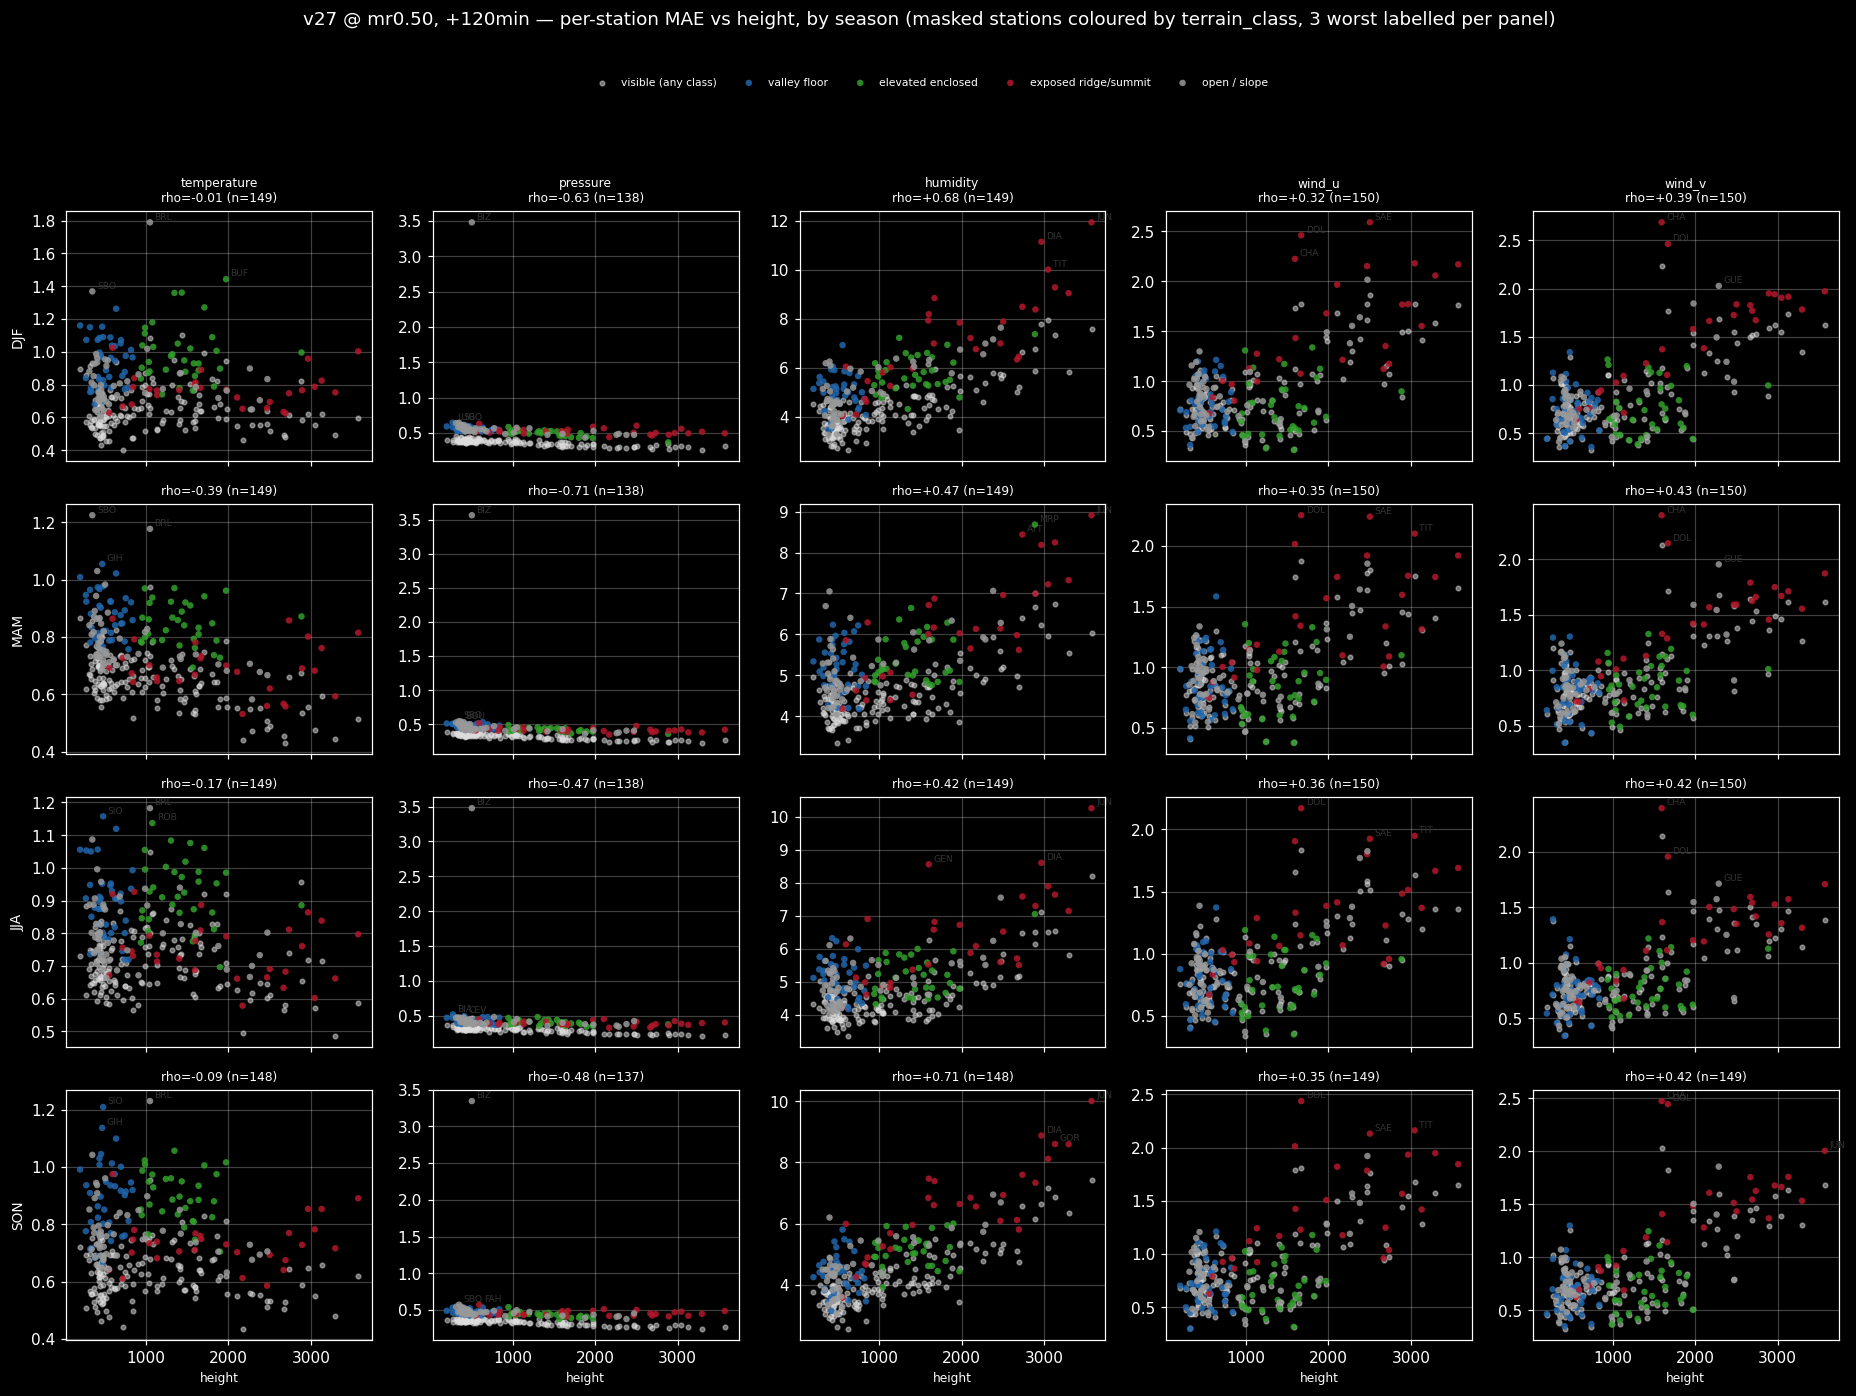

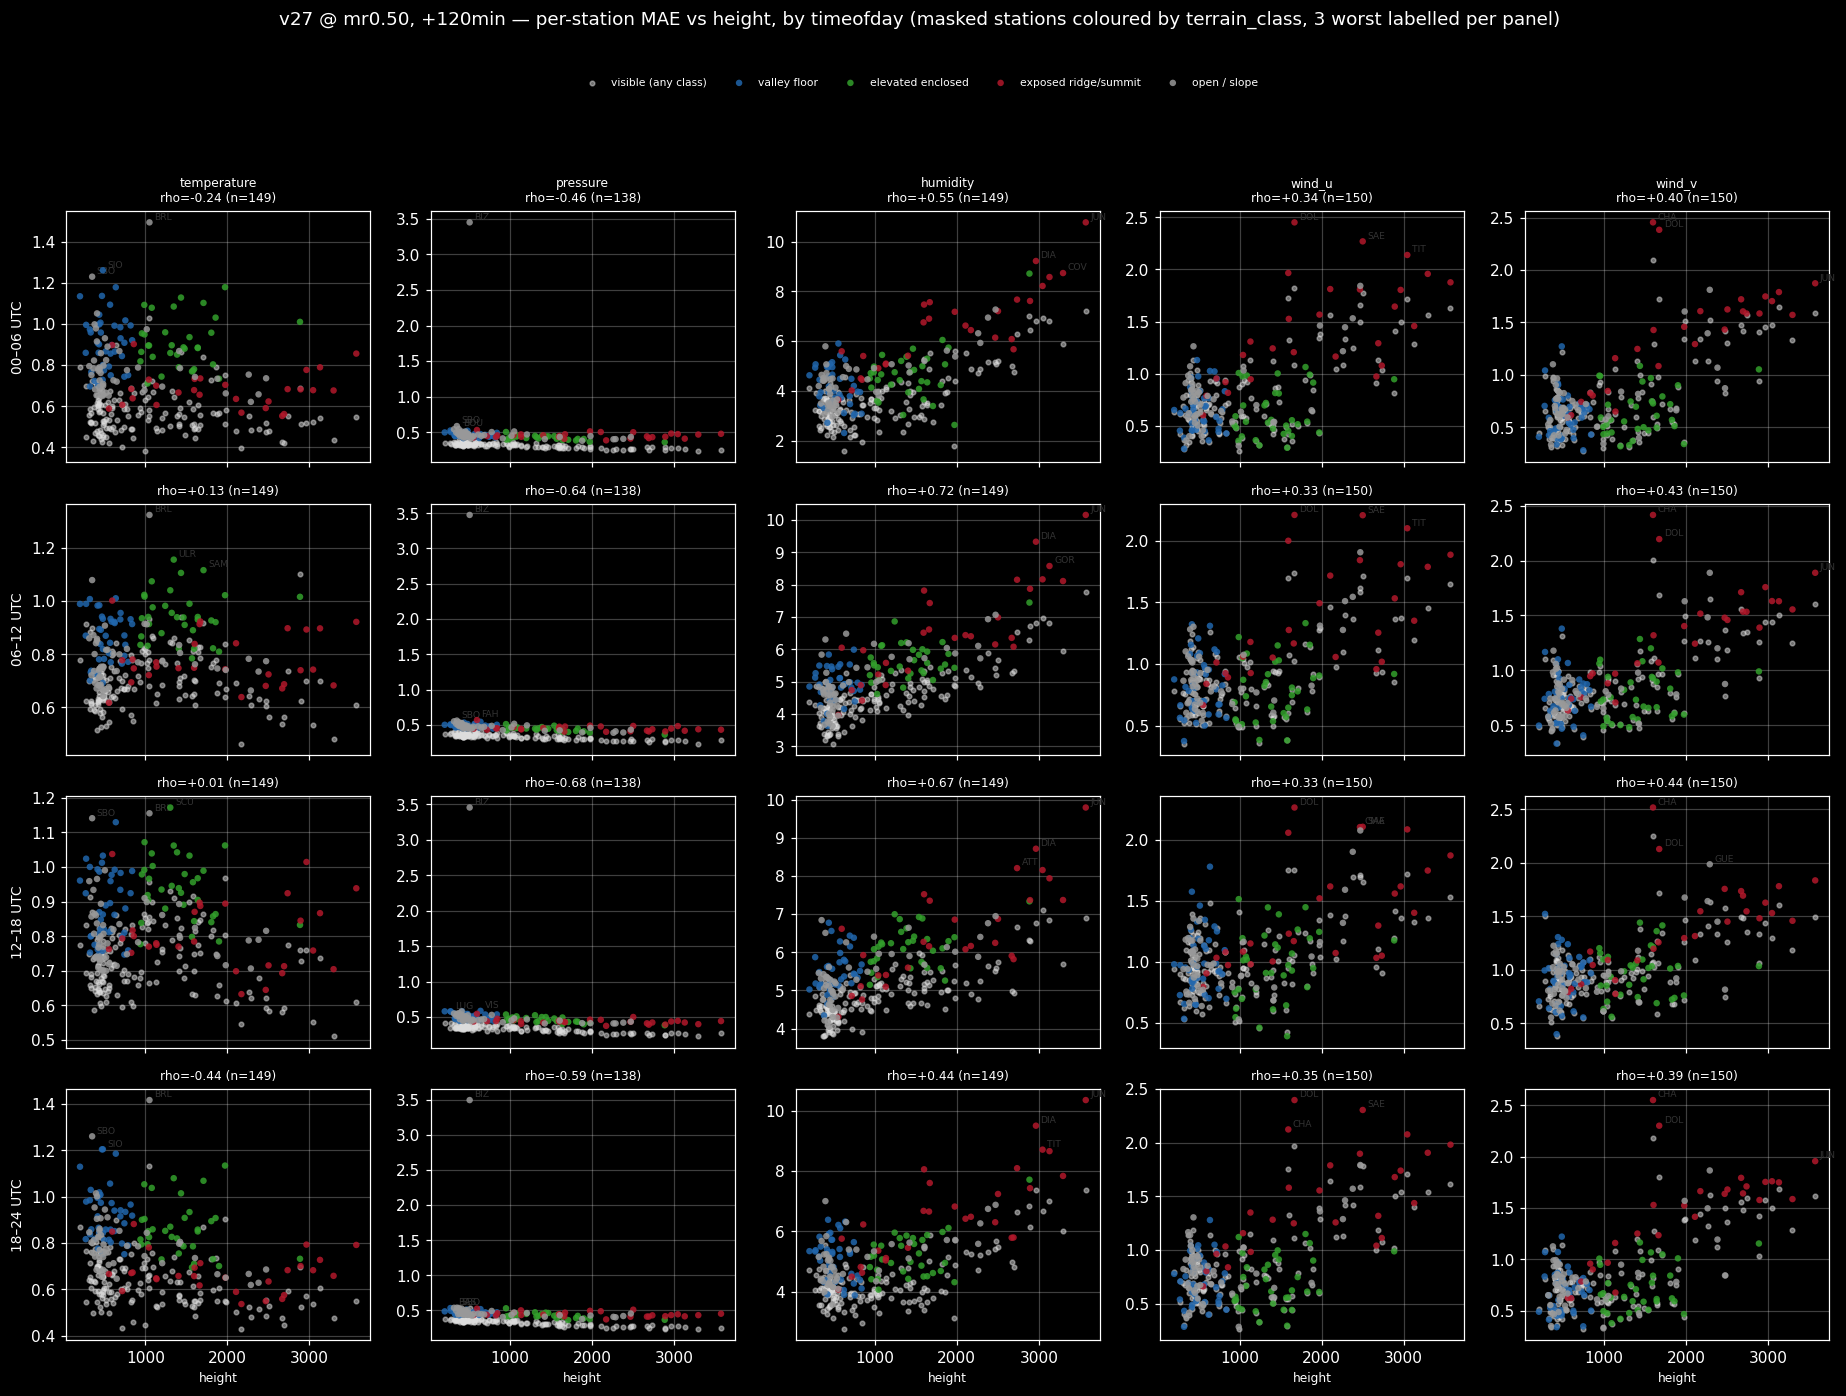

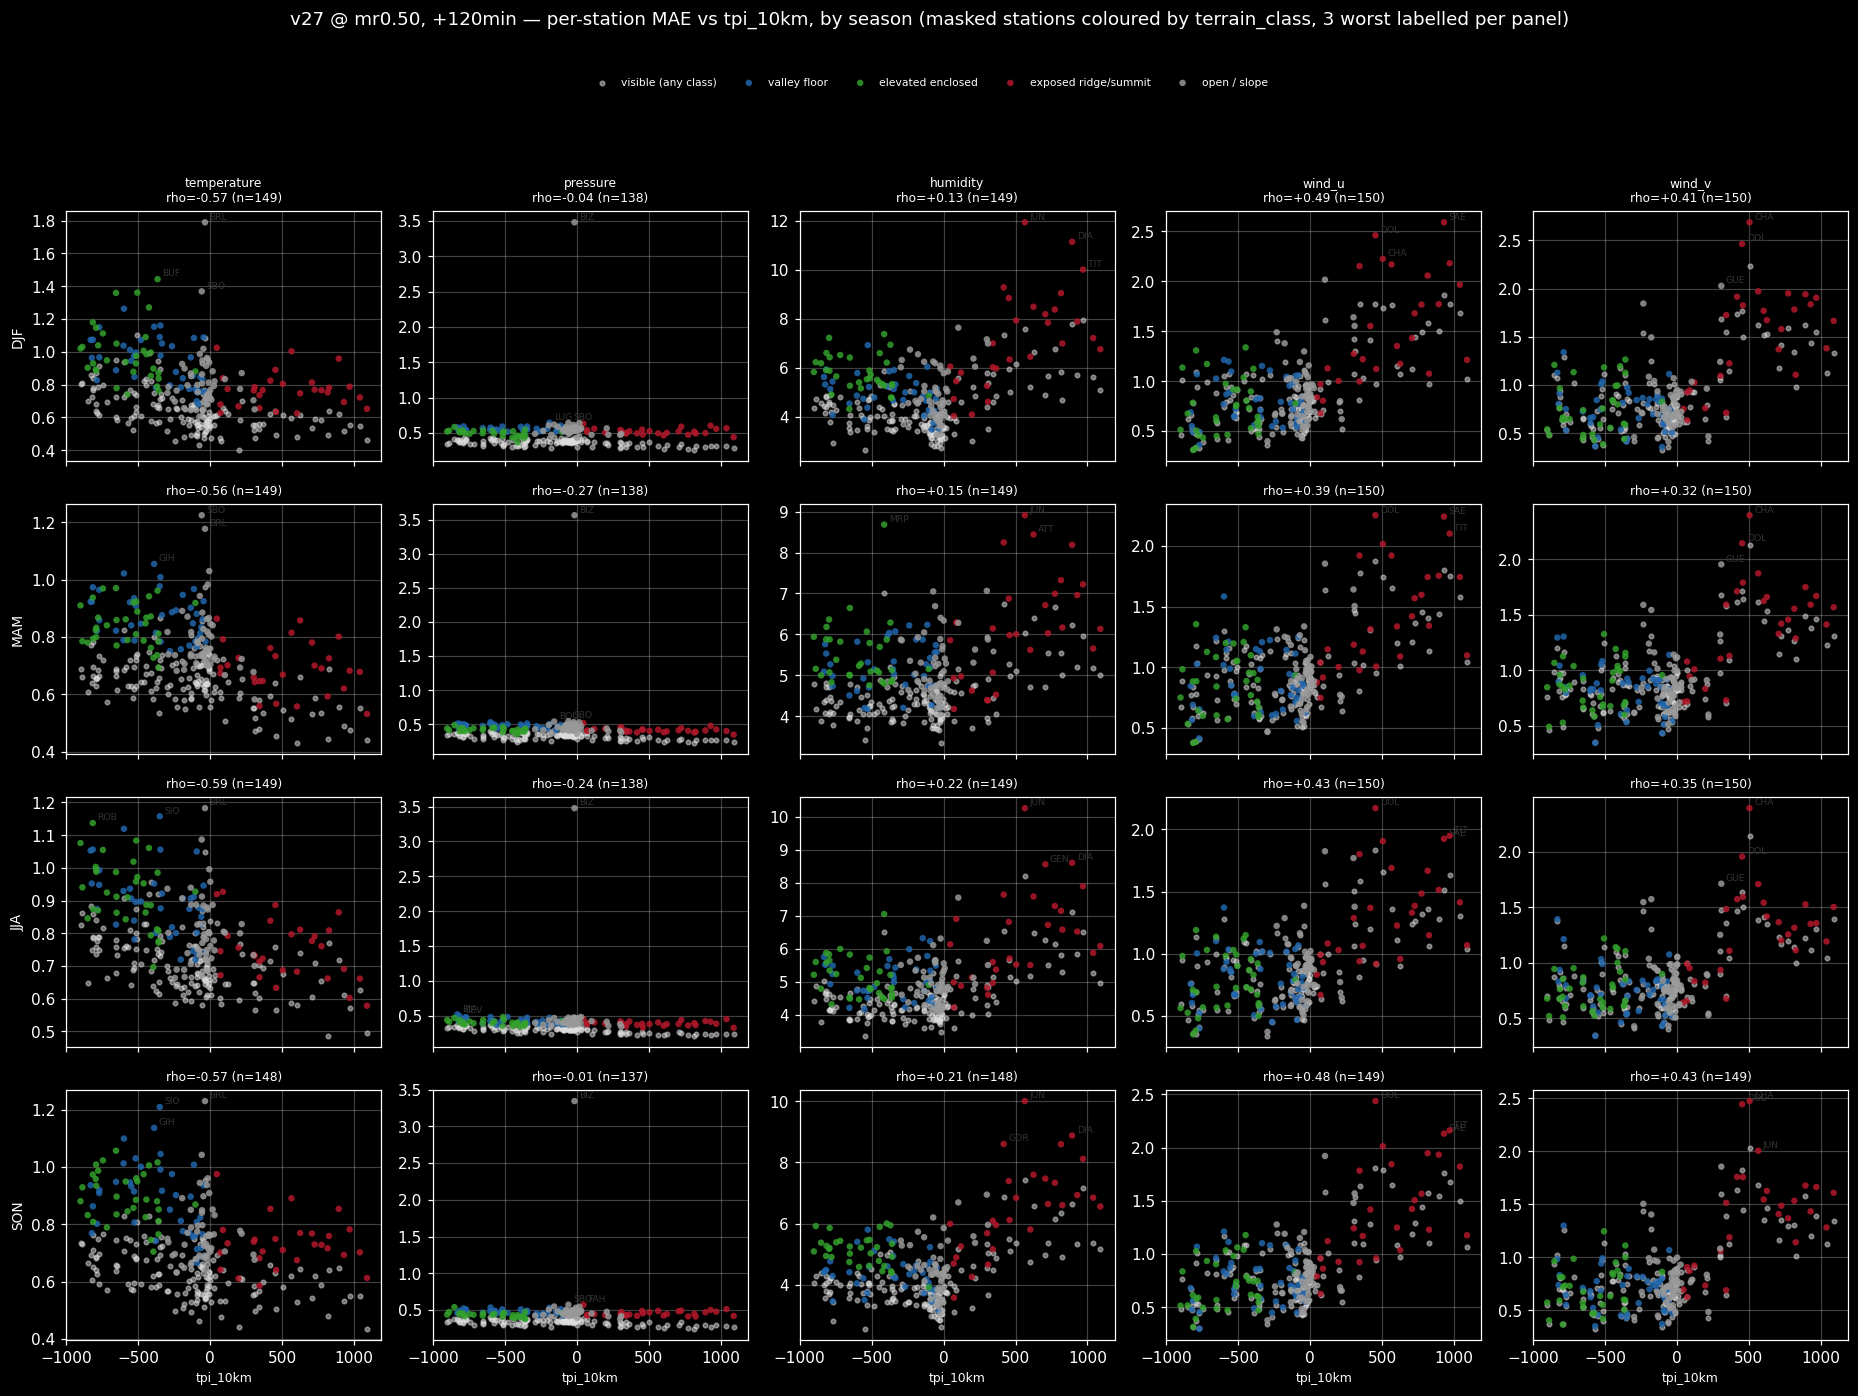

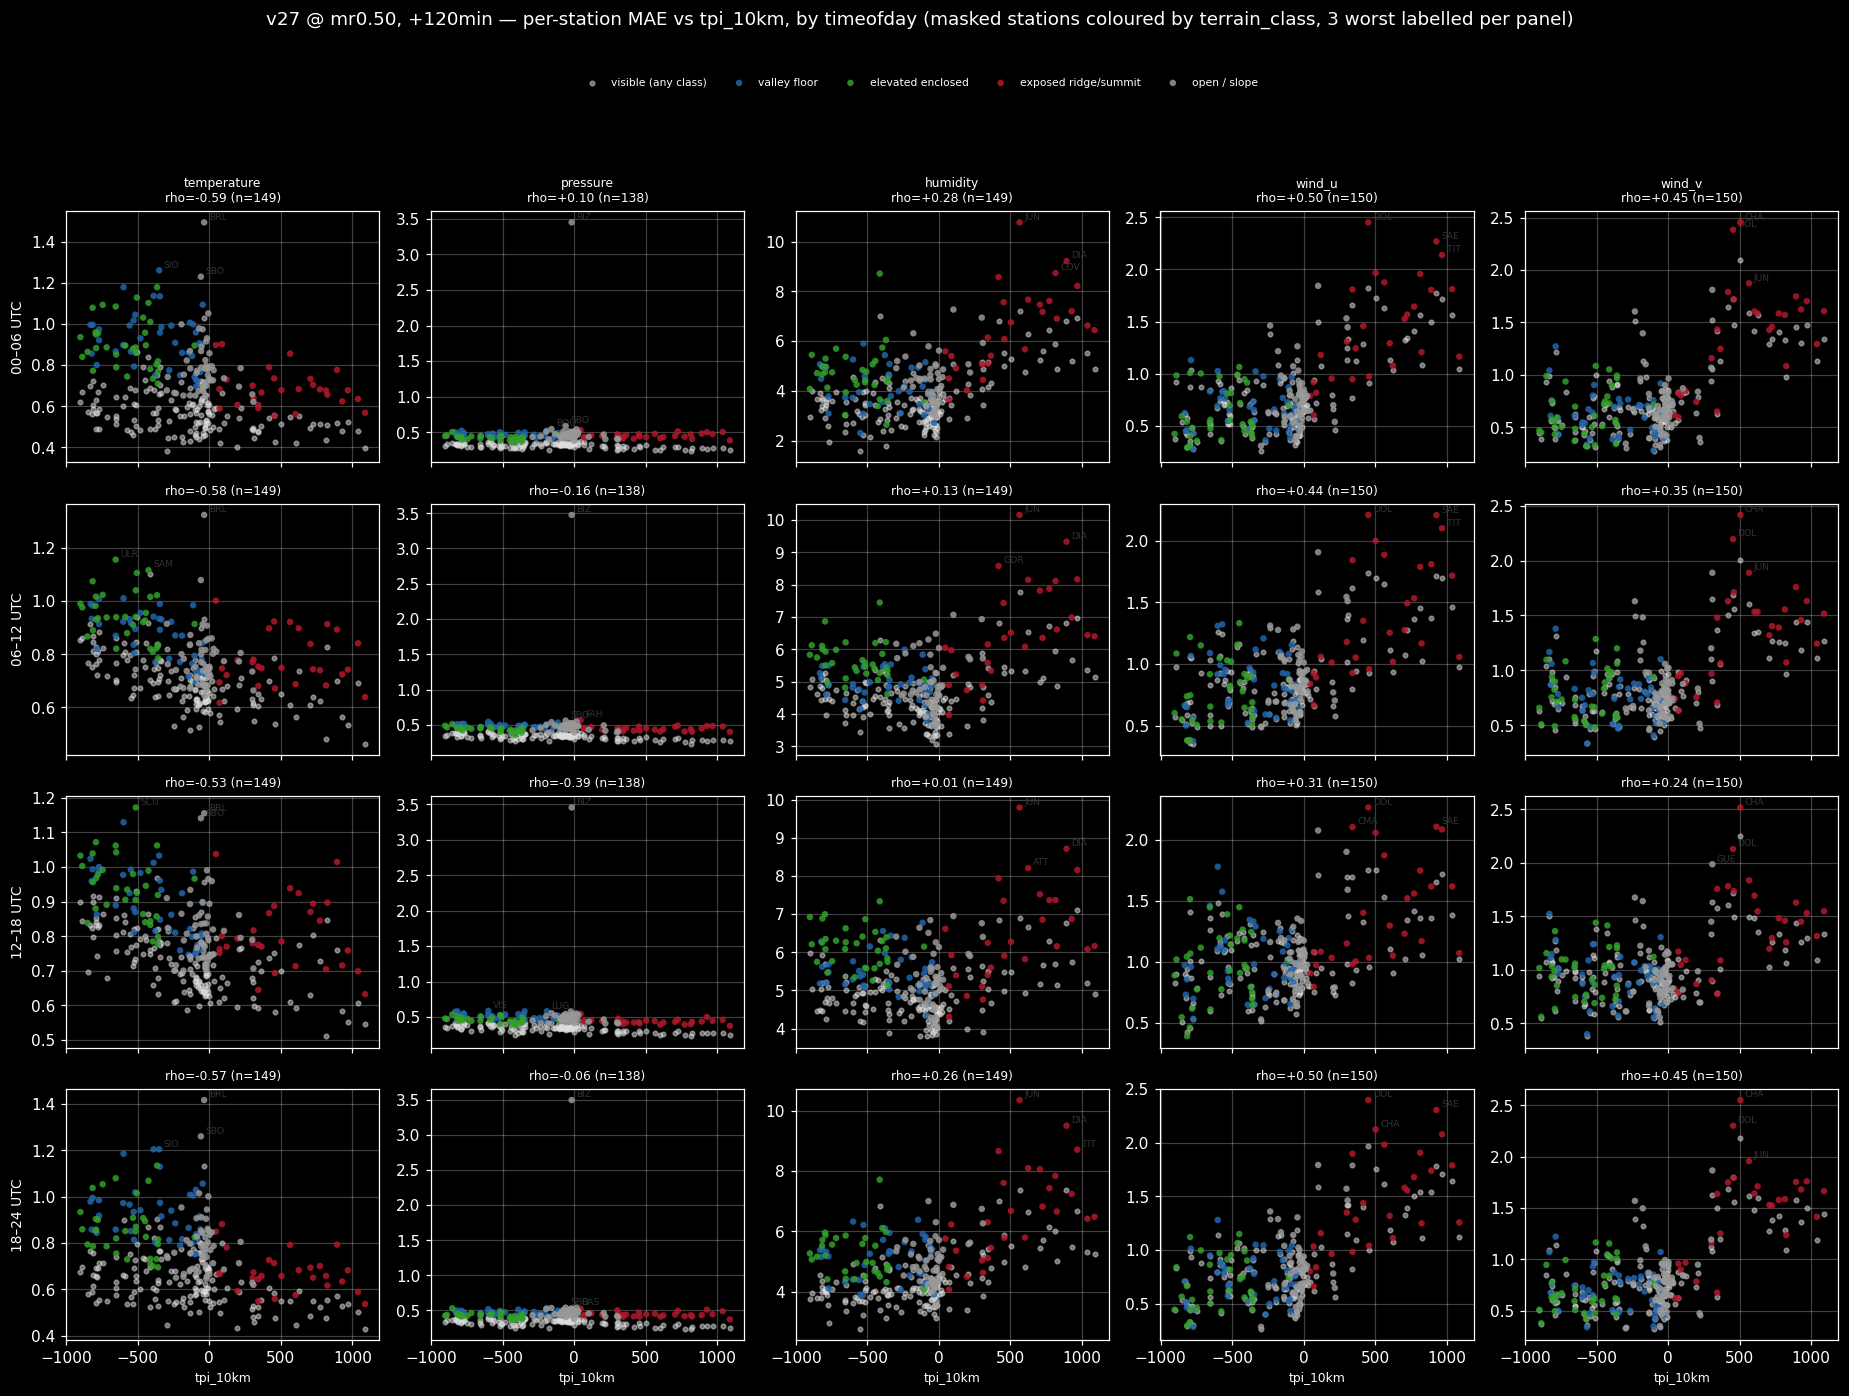

In [37]:
DESCRIPTORS_8 = ["height", "tpi_10km"]     # TPI_10000M, aliased in TOPO (S0)
N_LABEL = 3                                # stations labelled per panel

# stn.terrain_class (from common.py: station_table()) - four classes built from
# altitude-normalised TPI (shape) x a 900m inversion-cap height split (S0's own
# framework for exactly this kind of terrain question, so reused here rather
# than inventing a second classification).
TERRAIN_COLORS = {
    "valley floor":         "#2166AC",   # enclosed, below the winter inversion cap
    "elevated enclosed":    "#33A02C",   # same shape, above the cap
    "exposed ridge/summit": "#B2182B",
    "open / slope":         "#999999",
}
TERRAIN_ORDER = list(TERRAIN_COLORS)
_cats = stn.terrain_class.values
print("terrain_class counts:", {c: int((_cats == c).sum()) for c in TERRAIN_ORDER})

def scatter_station_grid(descriptor, mae_by_bin, labels, axis_name, subset_main="msk"):
    """
    rows = bin (season or time-of-day), cols = variable. Every station is one
    point (no pooling into a single statistic beyond the annotated rho),
    coloured by stn.terrain_class so category membership - not just position -
    is visible per point. The N_LABEL stations with the largest error in
    `subset_main` are labelled by abbreviation.
    """
    x_all = TOPO[descriptor].values
    fig, axes = plt.subplots(len(labels), len(VARS),
                             figsize=(3.4 * len(VARS), 2.9 * len(labels)),
                             sharex="col")
    for ri, lab in enumerate(labels):
        for ci, v in enumerate(VARS):
            ax = axes[ri, ci]
            y_vis = mae_by_bin["vis"][ri, :, ci]
            y_msk = mae_by_bin[subset_main][ri, :, ci]
            ax.scatter(x_all, y_vis, s=9, color="#DDDDDD", alpha=.5, zorder=3,
                      label="visible (any class)" if (ri == 0 and ci == 0) else None)
            for cat in TERRAIN_ORDER:
                sel = _cats == cat
                ax.scatter(x_all[sel], y_msk[sel], s=18, color=TERRAIN_COLORS[cat],
                          alpha=.85, zorder=4, edgecolors="none",
                          label=cat if (ri == 0 and ci == 0) else None)

            m = np.isfinite(x_all) & np.isfinite(y_msk)
            r = rho(x_all, y_msk)
            n = int(m.sum())
            if n >= N_LABEL:
                worst = np.argsort(np.where(m, y_msk, -np.inf))[::-1][:N_LABEL]
                for idx in worst:
                    if np.isfinite(y_msk[idx]):
                        ax.annotate(stn.abbr.values[idx], (x_all[idx], y_msk[idx]),
                                   fontsize=6, color="#333333",
                                   xytext=(3, 2), textcoords="offset points")

            ax.grid(alpha=.25)
            title = f"rho={r:+.2f} (n={n})" if np.isfinite(r) else f"n={n}"
            ax.set_title(f"{v}\n{title}" if ri == 0 else title, fontsize=8)
            if ci == 0:
                ax.set_ylabel(lab, fontsize=9)
            if ri == len(labels) - 1:
                ax.set_xlabel(descriptor, fontsize=8)
    fig.legend(fontsize=7, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.045),
              frameon=False)
    fig.suptitle(f"{RUN} @ {MR}, +{LEAD_MIN}min \u2014 per-station MAE vs {descriptor}, by {axis_name} "
                f"(masked stations coloured by terrain_class, {N_LABEL} worst labelled per panel)",
                y=1.09)
    plt.tight_layout()
    C.save_fig(fig, f"12_station_scatter_{descriptor}_by_{axis_name}")
    plt.show()

for desc in DESCRIPTORS_8:
    scatter_station_grid(desc, MAE_SEASON, SEASON_LABELS, "season")
    scatter_station_grid(desc, MAE_TOD, TOD_LABELS, "timeofday")


### 8b. Per-station table — no aggregation at all

The full per-station, per-season table for height and TPI_10km against
masked-station MAE, sorted by station so the same station's behaviour across
seasons and variables can be read off directly (rather than reduced to a
correlation). Saved in full to `analysis_outputs/tables/`; only a slice is
shown inline.

In [38]:
rows8 = []
for si, season in enumerate(SEASON_LABELS):
    for n in range(N):
        row = {"station": stn.abbr.values[n], "season": season,
              "height": TOPO["height"].values[n], "tpi_10km": TOPO["tpi_10km"].values[n]}
        for vi, v in enumerate(VARS):
            row[f"{v}_mae_msk"] = MAE_SEASON["msk"][si, n, vi]
            row[f"{v}_mae_vis"] = MAE_SEASON["vis"][si, n, vi]
        rows8.append(row)
station_table_8 = pd.DataFrame(rows8).sort_values(["station", "season"]).reset_index(drop=True)
C.save_table(station_table_8, "12_per_station_season_height_tpi")

print(f"{len(station_table_8)} rows (155 stations x 4 seasons) saved to "
     "analysis_outputs/tables/12_per_station_season_height_tpi.csv")
print("\nExample - the 5 highest-altitude stations, all seasons, temperature only:")
_high = station_table_8.sort_values("height", ascending=False)["station"].unique()[:5]
display(station_table_8[station_table_8.station.isin(_high)]
       [["station", "season", "height", "tpi_10km", "temperature_mae_msk", "temperature_mae_vis"]]
       .round(3))

print("\nExample - the 5 lowest-TPI (most valley-like) stations, all seasons, temperature only:")
_valley = station_table_8.sort_values("tpi_10km")["station"].unique()[:5]
display(station_table_8[station_table_8.station.isin(_valley)]
       [["station", "season", "height", "tpi_10km", "temperature_mae_msk", "temperature_mae_vis"]]
       .round(3))

620 rows (155 stations x 4 seasons) saved to analysis_outputs/tables/12_per_station_season_height_tpi.csv

Example - the 5 highest-altitude stations, all seasons, temperature only:


,station,season,height,tpi_10km,temperature_mae_msk,temperature_mae_vis
152,COV,DJF,3294.31,815.929,0.753,0.494
153,COV,JJA,3294.31,815.929,0.662,0.487
154,COV,MAM,3294.31,815.929,0.593,0.443
155,COV,SON,3294.31,815.929,0.717,0.481
172,DIA,DJF,2964.00,892.983,0.958,0.624
173,DIA,JJA,2964.00,892.983,0.864,0.719
174,DIA,MAM,2964.00,892.983,0.802,0.557
175,DIA,SON,2964.00,892.983,0.854,0.648
252,GOR,DJF,3129.17,417.901,0.825,0.623
253,GOR,JJA,3129.17,417.901,0.839,0.714



Example - the 5 lowest-TPI (most valley-like) stations, all seasons, temperature only:


,station,season,height,tpi_10km,temperature_mae_msk,temperature_mae_vis
52,BIA,DJF,278.00,-831.237,1.073,0.861
53,BIA,JJA,278.00,-831.237,1.053,0.882
54,BIA,MAM,278.00,-831.237,0.924,0.771
55,BIA,SON,278.00,-831.237,0.936,0.692
72,BLA,DJF,1538.00,-901.640,1.020,0.801
73,BLA,JJA,1538.00,-901.640,1.076,0.825
74,BLA,MAM,1538.00,-901.640,0.910,0.689
75,BLA,SON,1538.00,-901.640,0.881,0.733
148,COM,DJF,575.32,-823.026,0.963,0.725
149,COM,JJA,575.32,-823.026,0.952,0.750


**Reading this section.** Section 7 asked "is there a network-wide
relationship between height and error in DJF" — a question about the network
as a whole. This section asks "which specific stations does that
relationship come from" — a different, station-level question, and the two
can disagree: a pooled rho of −0.3 might be driven by five extreme high-altitude
stations while the other 150 show no relationship at all, which is invisible
in section 7 but is exactly what the labelled outliers and the per-station
table above are for.

## Interpretation

**Q1 — terrain.** Read the three panels together. A descriptor correlating with
error in *both* masked and visible columns describes intrinsic site
difficulty. One that appears only in the **penalty** column describes
reconstructability: how well the neighbours stand in for this site. If
`nn_dist_km` or `n_within_30km` dominate the penalty column while terrain
dominates the visible column, then site difficulty and reconstruction
difficulty have different causes — which is the cleanest possible statement of
what the spatial encoder is buying.

The joint fit in section 3 exists because height, slope, TPI and roughness are
mutually correlated: a marginal ρ of −0.5 on three descriptors may be one
effect counted three times. Trust the standardised coefficients over the
heatmap where they disagree, and note the R².

**Q2 — cycles.** `amp_ratio` is the headline. Values near 1 for visible
stations and meaningfully below 1 for masked ones would show the model
reconstructing hidden sites toward an average day — exactly the smoothing that
MAE rewards and cannot detect. Since this is measured at a fixed +2 h lead, a
damped diurnal cycle cannot be blamed on horizon length.

The seasonal panel is mostly a control: at +2 h the seasonal cycle should be
reproduced almost exactly, and a ratio far from 1 there would indicate a
normalisation problem rather than a forecasting one.

**Observations vs hypotheses.** Everything above is correlational. "Alpine
stations are hard because of unresolved katabatic drainage" is a hypothesis
this dataset cannot test — it carries no radiation or stability fields. State
the correlation, name the mechanism as a conjecture, and keep them apart.